Name:   Srujana Duggineni

ID:     C00313483

  #### Algorithm:  Linear Regression (custom Implementation)

  Dataset: 
   [Medical Insurance Dataset]

https://www.kaggle.com/datasets/arunjangir245/healthcare-insurance-expenses

1. Business Understanding:

Objective:

The objective of this work is to implement Linear Regression from custom, by using Gradient Descent; thereafter main comparisons will be drawn against the built-in methods from Scikit-Learn, and the effect of feature scaling on the performance of the model will be studied.
The broader aim will be therefore to get into a grounded grasp of Gradient Descent and hyperparameter tuning (like learning rate and epochs) as well as model evaluation using manual performance metrics such as Mean Squared Error (MSE).The challenges would be those in getting an optimal learning rate and epoch selection to achieve fast convergence while ensuring that the algorithm remains stable all through training.

 #### 2. Data Understanding 

Age: The insured person's age.

Sex: Gender (male or female) of the insured.

BMI (Body Mass Index): A measure of body fat based on height and weight.

Children: The number of dependents covered.

Smoker: Whether the insured is a smoker (yes or no).

Region: The geographic area of coverage.

Charges: The medical insurance costs incurred by the insured person.



In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from preprocess_data import preprocess_data
NUM_EPOCHS = 10000


#### 3. Preparing Dataset
The following EDA steps are followed (inside preprocess_data):
     1. Load dataset.
    2. Drop unwanted columns.
     3. Handle missing values.
    4. Encode categorical features.
    5. Process datetime features(NA)
    6. Remove outliers.
    7. Scale numerical features.
    8. Split into train & test sets.

In [2]:
# preprocessing dataset for classification
file_path = "/Users/dugginenisrujana/Desktop/DAA_CA /DAA_CA1/Datasets/insurance.csv"

### the column we want to predict
target_column = "charges" 

X_train, X_test, y_train, y_test = preprocess_data(file_path, target_column)

1. Load dataset.

First 5 Rows:
    age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

Dataset Info:
 None
2. Drop unwanted columns

 Preprocessing C

#### 4. Modelling 

  4.1 Baseline Implementation (custom) 

-  Initialize the model with a learning rate, epochs, and set weights and bias to zero.
- For each epoch: calculate predictions, compute gradients for weights and bias, and update them using gradient descent.
-Track the Mean Squared Error (MSE) for each epoch to monitor training progress.
- After all epochs, the weights and bias are optimized for the best fit.
- Use the trained model to predict target values for new input data using the learned weights and bias.

In [3]:
# 1. Linear Regression from custom
class LinearRegressioncustom:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.mse_history = []
        
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.epochs):
            y_predicted = np.dot(X, self.weights) + self.bias
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            # Compute and store MSE for this epoch
            mse = mean_squared_error(y, y_predicted)
            self.mse_history.append(mse)  
    def predict(self, X):
        return np.dot(X, self.weights) + self.bias




#### 5. Training and Evaluation

In [4]:
# Train & Evaluate Linear Regression
lin_reg_custom = LinearRegressioncustom(learning_rate=0.01, epochs=NUM_EPOCHS)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
lin_reg_custom.fit(X_train_scaled, y_train)


#### 5 a.Data visualisation and comparison

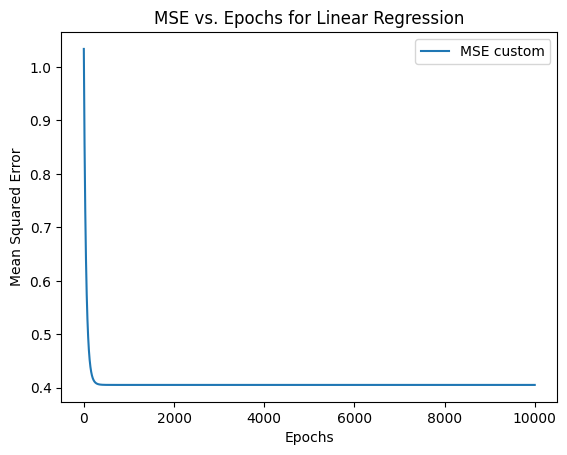

Linear Regression (custom) MSE: 0.3573
Linear Regression (Library) MSE: 0.3573


In [5]:
######
# Plot MSE over epochs
plt.plot(range(NUM_EPOCHS), lin_reg_custom.mse_history, label="MSE custom")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error")
plt.title("MSE vs. Epochs for Linear Regression")
plt.legend()
plt.show()

y_pred_custom = lin_reg_custom.predict(X_test_scaled)
mse_custom = mean_squared_error(y_test, y_pred_custom)

lin_reg_lib = LinearRegression()
lin_reg_lib.fit(X_train, y_train)
y_pred_lib = lin_reg_lib.predict(X_test)
mse_lib = mean_squared_error(y_test, y_pred_lib)

print(f"Linear Regression (custom) MSE: {mse_custom:.4f}")
print(f"Linear Regression (Library) MSE: {mse_lib:.4f}")

#### 5 b.Weights Comparison

In [6]:
print("custom Weights:", lin_reg_custom.weights, "Bias:", lin_reg_custom.bias)
print("Library Weights:", lin_reg_lib.coef_, "Bias:", lin_reg_lib.intercept_)

custom Weights: [ 0.77102202 -0.03996887  0.02863578  0.1281931   0.         -0.09903735] Bias: 0.019710644135906844
Library Weights: [ 0.76778539 -0.03997299  0.02876312  0.12682288  0.         -0.0994938 ] Bias: 0.007142318597261074


Observations: 
  - The MSE values for the custom implementation and Scikit-learn's Linear Regression are very close together,   which means that this custom implementation should be functioning correctly.
  - The weights learned by the two implementations differ. This is expected, especially since the implementation from custom uses gradient descent. 
  Gradient descent gets *a* minimum with respect to the loss surface, but it is not guaranteed to do it in the same way as the Normal Equation. 
  But the *performance* here counted by MSE turned out to be very similar, which is the key point.

In [7]:
from sklearn.metrics import mean_absolute_error, r2_score
### Checking other metrics for regression
# Evaluate additional metrics for the custom model
mae_custom = mean_absolute_error(y_test, y_pred_custom)
r2_custom = r2_score(y_test, y_pred_custom)
rmse_custom = np.sqrt(mse_custom)
# Evaluate additional metrics for the library model
mae_lib = mean_absolute_error(y_test, y_pred_lib)
r2_lib = r2_score(y_test, y_pred_lib)
rmse_lib = np.sqrt(mse_lib)

In [8]:
# Metrics comparison data
metrics = {
    "Metric": ["MSE", "MAE", "R²", "RMSE"],
    "Custom Model": [mse_custom, mae_custom, r2_custom, rmse_custom],
    "Library Model": [mse_lib, mae_lib, r2_lib, rmse_lib]
}

# Create a DataFrame to display the comparison
df_comparison = pd.DataFrame(metrics)

# Display the table
print(df_comparison)

  Metric  Custom Model  Library Model
0    MSE      0.357285       0.357285
1    MAE      0.289732       0.289732
2     R²      0.600727       0.600727
3   RMSE      0.597733       0.597733


Observations: 
  - The Metrics values for the custom implementation and Scikit-learn's Linear Regression are very close together,   which means that this custom implementation should be functioning correctly.

#### Saving model(future use)

In [9]:
import joblib  # Import joblib to save the model

# Saving the Custom Model
joblib.dump(LinearRegressioncustom, "custom_LinReg_model.pkl")


print("Models saved successfully!")

Models saved successfully!
